In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from ipywidgets import interact, fixed
from IPython.display import display, clear_output


In [2]:
def generate_data(n_samples=100, n_features=2, class_sep=1.0, random_state=37):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        class_sep=class_sep,
        random_state=random_state
    )
    return X, y

In [3]:
def plot_decision_boundary(model, X, y, show_support_vectors=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 1].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap = ListedColormap(['#FFAAAA', '#AAAAFF'])
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=70, alpha=.7)

    if model.kernel == 'linear' and hasattr(model, 'coef_'):
        w = model.coef_[0]
        a = -w[0] / w[1]
        b = -model.intercept_[0] / w[1]
        xx = np.linspace(x_min, x_max)
        yy = a * xx + b
        ax.plot(xx, yy, 'b-', label='Decision boundary')

        margin = 1 / np.sqrt(np.sum(model.coef_ ** 2))
        yy_down = yy - np.sqrt(1 + a ** 2) * margin
        yy_up = yy + np.sqrt(1 + a ** 2) * margin
        ax.plot(xx, yy_down, 'c--', label='Margin')
        ax.plot(xx, yy_up, 'c--', label='Margin')
        ax.legend()
        

    if show_support_vectors and hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                  s=200, facecolor='none', edgecolors='green', linewidth=2,
                  label='Support Vectors')
        ax.legend()

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    
    

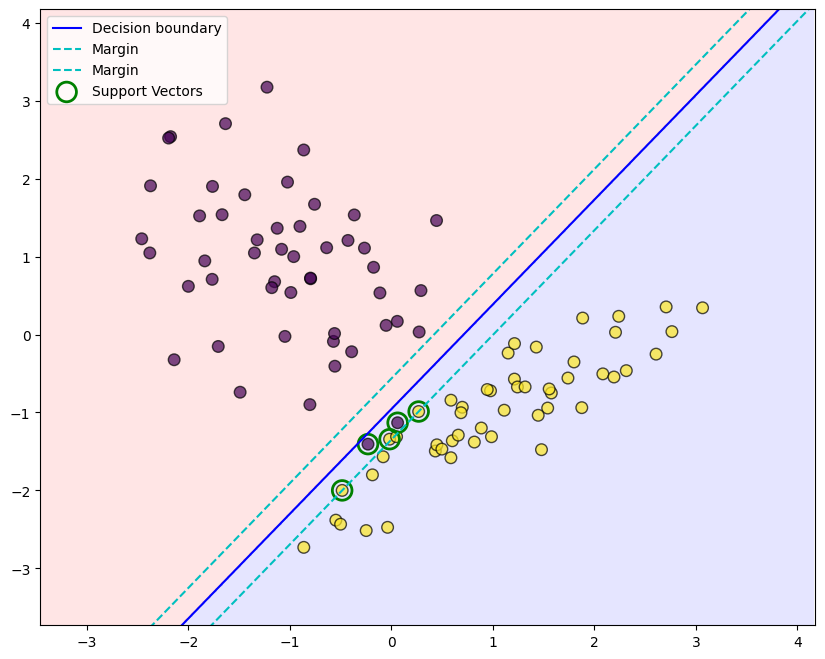

In [4]:
def illustrate_support_vectors():
    X, y = generate_data()

    svm_model = SVC(kernel='linear', C=20)
    svm_model.fit(X, y)
    plot_decision_boundary(svm_model, X, y)
    plt.show()
illustrate_support_vectors()

In [5]:
@interact(class_separation=(.5, 5, .1), n_samples=(50, 500, 10))
def visualize_data(class_separation=1.0, n_samples=100):
    X, y = generate_data(n_samples=n_samples, class_sep=class_separation)

    fig, ax = plt.subplots(figsize=(10,8))
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='lime', marker='o', s=80)
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='class_separation', max=5.0, min=0.5), IntSlider(valu…

In [6]:
def train_svm(X, y, kernel='linear', C=1.0):
    svm_model = SVC(kernel=kernel, C=C)
    svm_model.fit(X, y)
    return svm_model

def interactive_svm_training():
    X, y = generate_data(n_samples=200)
    kernel_selector = widgets.Dropdown(
        options=['linear', 'rbf', 'poly'],
        value='linear',
        description='Kernel:',
    
    )
    C_slider = widgets.FloatLogSlider(
        value=1.0,
        base=10,
        min=-2,
        max=2,
        step=.1,
        description='C:',
        continuous_update=False
    )
    plot_output = widgets.Output()
    def on_change(change):
        with plot_output:
            plot_output.clear_output()
            model = train_svm(X, y, kernel=kernel_selector.value, C=C_slider.value)
            fig, ax = plt.subplots(figsize=(10, 8))
            plot_decision_boundary(model, X, y, ax=ax, show_support_vectors=True)
            plt.show()

    kernel_selector.observe(on_change, names='value')
    C_slider.observe(on_change, names='value')

    on_change("")
    # with plot_output:
    #     model = train_svm(X, y, kernel=kernel_selector.value, C=C_slider.value)
    #     fig, ax = plt.subplots(figsize=(10, 8))
    #     plot_decision_boundary(model, X, y, ax=ax, show_support_vectors=False)
    #     plt.show()
        
    return widgets.VBox([widgets.HBox([kernel_selector, C_slider]), plot_output])

ui_output = widgets.Output()

button_train = widgets.Button(
    description="Train SVM Model",
    button_style='success',
    tooltip="Click to start interactive SVM training"
)

def on_button_train_clicked(b):
    with ui_output:
        ui_output.clear_output()
        display(interactive_svm_training())

button_train.on_click(on_button_train_clicked)

display(button_train, ui_output)
# display(interactive_svm_training())

Button(button_style='success', description='Train SVM Model', style=ButtonStyle(), tooltip='Click to start int…

Output()

In [7]:
def compare_margins():
    X, y = generate_data(n_samples=100, class_sep=1.0)

    C_slider = widgets.FloatLogSlider(
        value=1.0,
        base=10,
        min=-3,
        max=3,
        step=0.1,
        description="C value: ",
        continuous_update=False,
    )

    sv_toggle = widgets.Checkbox(
        value=True,
        description="Show support vectors",
    )
    plot_output = widgets.Output()

    def update_plot(C=1.0, show_sv=True):
        with plot_output:
            plot_output.clear_output()

            model_curr = SVC(kernel='linear', C=C)
            model_curr.fit(X, y)

            fig, ax = plt.subplots(figsize=(12, 10))
            plot_decision_boundary(model_curr, X, y, show_support_vectors=show_sv, ax=ax)
            ax.set_title(f'SVM with C={C:.3f}')
            plt.show()
            
    widgets.interactive_output(update_plot, {'C': C_slider, 'show_sv': sv_toggle})

    update_plot()
    controls = widgets.HBox([C_slider, sv_toggle])
    ui = widgets.VBox([controls, plot_output])
    return ui


output = widgets.Output()

button_compare = widgets.Button(
    description="Compare Margins",
    button_style="primary",
)

def on_button_compare_click(b):
    with output:
        display(compare_margins())
        
button_compare.on_click(on_button_compare_click)

display(button_compare, output)

Button(button_style='primary', description='Compare Margins', style=ButtonStyle())

Output()